# Homework 04 - Pedestrian Detection Dataset (Group-based ML-Task)

Contact: David C. Schedl (david.schedl@fh-hagenberg.at)

Note: this is the starter pack for the **Digital Imaging / Computer Vision** homework. You do not need to use the exact same template and can start from scratch as well!
Using regular Python files (.py) is also possible.

## Task Overview

The goal of this group-based machine-learning task is to work with the Pedestrian Detection Dataset that we created together and evaluate the performance of our trained YOLO model. This assignment focuses on practical experience with object detection workflows and critical analysis of model performance.

**Dataset Reference**: Use the pedestrian dataset and trained model from `10_OD.ipynb` as your starting point.

# Tasks

## Model Performance Evaluation
Analyze the overall model performance using the validation metrics:
- Interpret the validation results from the model evaluation
- Compare performance between different object classes (crossing vs waiting pedestrians)

## Model Testing and Analysis
Test the trained YOLO model on different images from the pedestrian dataset:
- Select at least 5 different test images from `data/Pedestrian-Detection/test/images/`
- Analyze detection results for each image
- Document which objects (crossing, waiting pedestrians) are detected correctly and which are missed
- Compare detection performance across different image scenarios

## Failure Case Analysis
Identify and analyze cases where the model performs poorly:
- Find images with false positives (incorrect detections)
- Find images with false negatives (missed objects)
- Analyze what factors contribute to poor performance:
  - Image quality and lighting conditions
  - Object size and visibility
  - Background complexity, clutter and occlusion
  - Camera angle and perspective
- Document your findings with specific examples
- Are there potential issues in the dataset?

## Dataset Contribution Documentation
Document your individual contribution to the Pedestrian Detection Dataset creation process:

**Image Collection (if applicable)**: Describe your role in gathering pedestrian images (if applicable)
- What sources did you use (video frames, online sources, etc.)?
- What criteria did you use for image selection?

**Image Labeling**: Detail your labeling work on Roboflow
- What challenges did you encounter during labeling (e.g. distinguishing crossing vs waiting pedestrians)?
- How did you ensure labeling consistency and quality?




**Focus on critical thinking and analysis rather than just completing the technical steps.**

In [6]:
!pip install ultralytics -q

from pathlib import Path
import os
import shutil
import urllib.request
import zipfile

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ultralytics import YOLO

In [7]:
PROJECT_ROOT = Path.cwd()

ARCHIVE_PATH = PROJECT_ROOT / "pedestrian-detection-dataset.zip"
DATASET_ROOT = PROJECT_ROOT / "data" / "Pedestrian-Detection"

DATASET_URL = "https://raw.githubusercontent.com/Digital-Media/cv_data/main/pedestrian-detection-dataset.zip"

if not ARCHIVE_PATH.exists():
    urllib.request.urlretrieve(DATASET_URL, ARCHIVE_PATH)

if not DATASET_ROOT.exists():
    (PROJECT_ROOT / "data").mkdir(exist_ok=True)
    with zipfile.ZipFile(ARCHIVE_PATH, "r") as archive:
        archive.extractall(PROJECT_ROOT / "data")

print("Dataset path:", DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())

Dataset path: /content/data/Pedestrian-Detection
Exists: True


In [8]:
MODEL_PATH = DATASET_ROOT / "models" / "weights.pt"
DATA_YAML = DATASET_ROOT / "data.yaml"

print("Model exists:", MODEL_PATH.exists())
print("Data yaml exists:", DATA_YAML.exists())

model = YOLO(MODEL_PATH)

class_names = dict(model.names)

print("Model task:", model.task)
print("Classes:", class_names)

Model exists: True
Data yaml exists: True
Model task: detect
Classes: {0: 'crossing', 1: 'waiting pedestrian'}


In [9]:
def scan_split(split):
    image_files = sorted((DATASET_ROOT / split / "images").glob("*"))
    label_files = sorted((DATASET_ROOT / split / "labels").glob("*.txt"))

    class_counts = {class_id: 0 for class_id in class_names}
    box_labels = 0
    polygon_labels = 0
    empty_labels = 0

    for label_file in label_files:
        lines = [line for line in label_file.read_text().splitlines() if line.strip()]

        if not lines:
            empty_labels += 1

        for line in lines:
            tokens = line.split()
            class_id = int(tokens[0])
            class_counts[class_id] += 1

            if len(tokens) == 5:
                box_labels += 1
            else:
                polygon_labels += 1

    return {
        "split": split,
        "images": len(image_files),
        "objects": sum(class_counts.values()),
        "crossing": class_counts.get(0, 0),
        "waiting pedestrian": class_counts.get(1, 0),
        "box labels": box_labels,
        "polygon labels": polygon_labels,
        "negative images": empty_labels,
    }

dataset_summary = pd.DataFrame([
    scan_split("train"),
    scan_split("valid"),
    scan_split("test")
])

display(dataset_summary)

,split,images,objects,crossing,waiting pedestrian,box labels,polygon labels,negative images
0,train,592,2058,826,1232,1580,478,22
1,valid,82,301,102,199,236,65,4
2,test,78,275,126,149,213,62,0


In [10]:
EVALUATION_ROOT = PROJECT_ROOT / "evaluation-data"
EVALUATION_YAML = EVALUATION_ROOT / "data.yaml"

def annotation_as_detection_box(line):
    values = [float(value) for value in line.split()]
    class_id = int(values[0])
    coordinates = values[1:]

    if len(coordinates) == 4:
        center_x, center_y, width, height = coordinates
    else:
        points = np.array(coordinates).reshape(-1, 2)
        minimum = points.min(axis=0)
        maximum = points.max(axis=0)

        center_x, center_y = (minimum + maximum) / 2
        width, height = maximum - minimum

    return class_id, center_x, center_y, width, height


def prepare_validation_dataset():
    source_images = sorted((DATASET_ROOT / "valid" / "images").glob("*"))
    source_labels = DATASET_ROOT / "valid" / "labels"

    target_images = EVALUATION_ROOT / "images"
    target_labels = EVALUATION_ROOT / "labels"

    target_images.mkdir(parents=True, exist_ok=True)
    target_labels.mkdir(parents=True, exist_ok=True)

    converted_objects = 0

    for image_path in source_images:
        shutil.copy2(image_path, target_images / image_path.name)

        source_label = source_labels / f"{image_path.stem}.txt"
        converted_lines = []

        if source_label.exists():
            for line in source_label.read_text(encoding="utf-8").splitlines():
                if not line.strip():
                    continue

                class_id, center_x, center_y, width, height = annotation_as_detection_box(line)

                converted_lines.append(
                    f"{class_id} {center_x:.8f} {center_y:.8f} {width:.8f} {height:.8f}"
                )

                converted_objects += 1

        label_text = "\n".join(converted_lines)

        if label_text:
            label_text += "\n"

        (target_labels / f"{image_path.stem}.txt").write_text(label_text, encoding="utf-8")

    yaml_text = (
        f"path: {EVALUATION_ROOT.as_posix()}\n"
        "train: images\n"
        "val: images\n"
        "test: images\n"
        "names: ['crossing', 'waiting pedestrian']\n"
    )

    EVALUATION_YAML.write_text(yaml_text, encoding="utf-8")

    return {
        "images": len(source_images),
        "objects": converted_objects,
        "yaml": str(EVALUATION_YAML)
    }


evaluation_dataset = prepare_validation_dataset()
print(evaluation_dataset)

{'images': 82, 'objects': 301, 'yaml': '/content/evaluation-data/data.yaml'}


In [11]:
metrics_val = model.val(
    data=str(EVALUATION_YAML),
    split="val",
    device="cpu",
    plots=True,
    verbose=False
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 416.6±111.7 MB/s, size: 60.4 KB)
val: Scanning /content/evaluation-data/labels... 82 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 642.1it/s 0.1s
val: New cache created: /content/evaluation-data/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 4.4s/it 26.4s
                   all         82        301      0.763      0.684      0.723      0.391
Speed: 11.1ms preprocess, 294.5ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val


In [12]:
metric_rows = [{
    "class": "all",
    "precision": metrics_val.box.mp,
    "recall": metrics_val.box.mr,
    "mAP50": metrics_val.box.map50,
    "mAP50-95": metrics_val.box.map,
}]

for class_id in metrics_val.box.ap_class_index.astype(int):
    precision, recall, map50, map50_95 = metrics_val.box.class_result(class_id)

    metric_rows.append({
        "class": class_names[class_id],
        "precision": precision,
        "recall": recall,
        "mAP50": map50,
        "mAP50-95": map50_95,
    })

validation_metrics = pd.DataFrame(metric_rows)

display(validation_metrics.style.format({
    "precision": "{:.2%}",
    "recall": "{:.2%}",
    "mAP50": "{:.2%}",
    "mAP50-95": "{:.2%}",
}))

,class,precision,recall,mAP50,mAP50-95
0,all,76.30%,68.42%,72.29%,39.08%
1,crossing,77.74%,73.53%,78.12%,47.89%
2,waiting pedestrian,74.87%,63.32%,66.46%,30.27%


In [13]:
CONFIDENCE_THRESHOLD = 0.25
IOU_THRESHOLD = 0.50


def load_ground_truth(label_path, image_width, image_height):
    ground_truth = []

    if not label_path.exists():
        return ground_truth

    for line in label_path.read_text().splitlines():
        if not line.strip():
            continue

        values = [float(value) for value in line.split()]
        class_id = int(values[0])
        coordinates = values[1:]

        if len(coordinates) == 4:
            center_x, center_y, width, height = coordinates

            box = np.array([
                (center_x - width / 2) * image_width,
                (center_y - height / 2) * image_height,
                (center_x + width / 2) * image_width,
                (center_y + height / 2) * image_height,
            ])
        else:
            points = np.array(coordinates).reshape(-1, 2)

            minimum = points.min(axis=0) * [image_width, image_height]
            maximum = points.max(axis=0) * [image_width, image_height]

            box = np.concatenate([minimum, maximum])

        ground_truth.append({
            "class_id": class_id,
            "box": box
        })

    return ground_truth


def box_iou(box_a, box_b):
    intersection_min = np.maximum(box_a[:2], box_b[:2])
    intersection_max = np.minimum(box_a[2:], box_b[2:])

    intersection = np.prod(np.maximum(0.0, intersection_max - intersection_min))

    area_a = np.prod(np.maximum(0.0, box_a[2:] - box_a[:2]))
    area_b = np.prod(np.maximum(0.0, box_b[2:] - box_b[:2]))

    union = area_a + area_b - intersection

    return intersection / union if union > 0 else 0.0


def match_predictions(ground_truth, predictions, iou_threshold=0.5):
    unmatched_ground_truth = set(range(len(ground_truth)))
    matched_ground_truth = set()
    matched_predictions = set()

    for prediction_index in sorted(
        range(len(predictions)),
        key=lambda index: predictions[index]["confidence"],
        reverse=True
    ):
        prediction = predictions[prediction_index]

        candidates = [
            (box_iou(prediction["box"], ground_truth[index]["box"]), index)
            for index in unmatched_ground_truth
            if ground_truth[index]["class_id"] == prediction["class_id"]
        ]

        best_iou, best_index = max(candidates, default=(0.0, None))

        if best_iou >= iou_threshold:
            matched_predictions.add(prediction_index)
            matched_ground_truth.add(best_index)
            unmatched_ground_truth.remove(best_index)

    return matched_ground_truth, matched_predictions

In [14]:
test_image_paths = sorted((DATASET_ROOT / "test" / "images").glob("*"))

test_results = model.predict(
    source=[str(path) for path in test_image_paths],
    conf=CONFIDENCE_THRESHOLD,
    iou=0.70,
    imgsz=640,
    device="cpu",
    verbose=False
)

analysis_records = []
evaluation_details = {}

class_totals = {
    class_id: {
        "ground truth": 0,
        "predictions": 0,
        "TP": 0,
        "FP": 0,
        "FN": 0
    }
    for class_id in class_names
}

for image_path, result in zip(test_image_paths, test_results):
    image_height, image_width = result.orig_shape

    label_path = DATASET_ROOT / "test" / "labels" / f"{image_path.stem}.txt"

    ground_truth = load_ground_truth(label_path, image_width, image_height)

    predictions = []

    if result.boxes is not None:
        for class_id, confidence, box in zip(
            result.boxes.cls.cpu().numpy(),
            result.boxes.conf.cpu().numpy(),
            result.boxes.xyxy.cpu().numpy()
        ):
            predictions.append({
                "class_id": int(class_id),
                "confidence": float(confidence),
                "box": box.astype(float)
            })

    matched_ground_truth, matched_predictions = match_predictions(
        ground_truth,
        predictions,
        IOU_THRESHOLD
    )

    true_positives = len(matched_predictions)
    false_positives = len(predictions) - true_positives
    false_negatives = len(ground_truth) - true_positives

    analysis_records.append({
        "image": image_path.name,
        "ground truth": len(ground_truth),
        "predictions": len(predictions),
        "TP": true_positives,
        "FP": false_positives,
        "FN": false_negatives
    })

    for class_id in class_names:
        gt_count = sum(item["class_id"] == class_id for item in ground_truth)
        prediction_count = sum(item["class_id"] == class_id for item in predictions)

        tp_count = sum(
            predictions[index]["class_id"] == class_id
            for index in matched_predictions
        )

        class_totals[class_id]["ground truth"] += gt_count
        class_totals[class_id]["predictions"] += prediction_count
        class_totals[class_id]["TP"] += tp_count
        class_totals[class_id]["FP"] += prediction_count - tp_count
        class_totals[class_id]["FN"] += gt_count - tp_count

    evaluation_details[image_path.name] = {
        "path": image_path,
        "ground_truth": ground_truth,
        "predictions": predictions,
        "matched_ground_truth": matched_ground_truth,
        "matched_predictions": matched_predictions
    }

test_summary = pd.DataFrame(analysis_records)

display(test_summary.head())

,image,ground truth,predictions,TP,FP,FN
0,11_jpg.rf.8f4aa759170b6c3d62aa3b76c32252e4.jpg,8,3,3,0,5
1,16_jpg.rf.bd2a6e51147daa8392053f65cb9fadc9.jpg,5,7,5,2,0
2,22_jpg.rf.5afa0de3f3e9db0099fafea7a595200b.jpg,4,4,4,0,0
3,23_jpg.rf.90ba8a35a16956985952a2031c811850.jpg,4,4,3,1,1
4,27_jpg.rf.df4485435babcc531c40ff22d8151f3e.jpg,1,1,1,0,0


In [15]:
test_class_rows = []

for class_id, totals in class_totals.items():
    precision = totals["TP"] / (totals["TP"] + totals["FP"]) if (totals["TP"] + totals["FP"]) > 0 else 0
    recall = totals["TP"] / (totals["TP"] + totals["FN"]) if (totals["TP"] + totals["FN"]) > 0 else 0

    test_class_rows.append({
        "class": class_names[class_id],
        **totals,
        "precision": precision,
        "recall": recall
    })

test_class_metrics = pd.DataFrame(test_class_rows)

display(test_class_metrics.style.format({
    "precision": "{:.2%}",
    "recall": "{:.2%}"
}))

print("Test images:", len(test_summary))
print("Total TP:", test_summary["TP"].sum())
print("Total FP:", test_summary["FP"].sum())
print("Total FN:", test_summary["FN"].sum())
print("Perfect images:", ((test_summary["FP"] == 0) & (test_summary["FN"] == 0)).sum())
print("Images with false positives:", (test_summary["FP"] > 0).sum())
print("Images with false negatives:", (test_summary["FN"] > 0).sum())

,class,ground truth,predictions,TP,FP,FN,precision,recall
0,crossing,126,158,102,56,24,64.56%,80.95%
1,waiting pedestrian,149,182,113,69,36,62.09%,75.84%


Test images: 78
Total TP: 215
Total FP: 125
Total FN: 60
Perfect images: 14
Images with false positives: 55
Images with false negatives: 34


In [16]:
perfect_cases = test_summary[(test_summary["FP"] == 0) & (test_summary["FN"] == 0)]
false_positive_cases = test_summary[test_summary["FP"] > 0].sort_values("FP", ascending=False)
false_negative_cases = test_summary[test_summary["FN"] > 0].sort_values("FN", ascending=False)

print("Perfekte Beispiele:")
display(perfect_cases.head(5))

print("Viele False Positives:")
display(false_positive_cases.head(5))

print("Viele False Negatives:")
display(false_negative_cases.head(5))

Perfekte Beispiele:


,image,ground truth,predictions,TP,FP,FN
2,22_jpg.rf.5afa0de3f3e9db0099fafea7a595200b.jpg,4,4,4,0,0
4,27_jpg.rf.df4485435babcc531c40ff22d8151f3e.jpg,1,1,1,0,0
10,IMG_1776_jpg.rf.94cc5db1f7b931ead014d5cd141db3...,1,1,1,0,0
13,NegP_17_jpg.rf.be36a9c34bd5b3d3cd58694b15947ca...,1,1,1,0,0
14,NegP_24_jpg.rf.8c4312e603a740042351e2b70eeeac7...,1,1,1,0,0


Viele False Positives:


,image,ground truth,predictions,TP,FP,FN
20,Screenshot-2025-06-17-at-3_02_46-PM_jpeg_jpeg_...,9,20,9,11,0
32,Screenshot-2025-06-21-at-7_25_50-PM_jpeg_jpeg_...,3,14,3,11,0
44,b60f1db0-b9889ec7_jpg.rf.591566ade14510ece9c09...,8,14,7,7,1
33,algivari-rizchy-UOXLfnh3X0A-unsplash_jpg.rf.dc...,7,10,6,4,1
29,Screenshot-2025-06-21-at-6_35_01-PM_jpeg_jpeg_...,6,7,3,4,3


Viele False Negatives:


,image,ground truth,predictions,TP,FP,FN
39,b33ea6cb-8ef8b9c4_jpg.rf.b6d48ca9579b77e3950d9...,15,6,5,1,10
0,11_jpg.rf.8f4aa759170b6c3d62aa3b76c32252e4.jpg,8,3,3,0,5
72,pexels-david-vives-1474251-36568724_jpg.rf.f5f...,7,8,4,4,3
29,Screenshot-2025-06-21-at-6_35_01-PM_jpeg_jpeg_...,6,7,3,4,3
40,b36de7af-08e5967a_jpg.rf.aa44b1bdf592592d4aa07...,3,1,0,1,3


In [17]:
selected_images = [
    "b4c8a6c7-56206227_jpg.rf.2168ccd3692a40a34b1060ddb163c297.jpg",
    "27_jpg.rf.df4485435babcc531c40ff22d8151f3e.jpg",
    "b33ea6cb-8ef8b9c4_jpg.rf.b6d48ca9579b77e3950d9b9a87882939.jpg",
    "Screenshot-2025-06-17-at-3_02_46-PM_jpeg_jpeg_jpeg.rf.38e76c04ddd6b139fc2e90cdaeea1061.jpg",
    "heon_IMG_0570_JPG.rf.aec9f7141d0a1fbccf9217f902a70199.jpg",
    "11_jpg.rf.8f4aa759170b6c3d62aa3b76c32252e4.jpg",
]

selected_table = test_summary.set_index("image").loc[selected_images].reset_index()

display(selected_table)

,image,ground truth,predictions,TP,FP,FN
0,b4c8a6c7-56206227_jpg.rf.2168ccd3692a40a34b106...,5,5,5,0,0
1,27_jpg.rf.df4485435babcc531c40ff22d8151f3e.jpg,1,1,1,0,0
2,b33ea6cb-8ef8b9c4_jpg.rf.b6d48ca9579b77e3950d9...,15,6,5,1,10
3,Screenshot-2025-06-17-at-3_02_46-PM_jpeg_jpeg_...,9,20,9,11,0
4,heon_IMG_0570_JPG.rf.aec9f7141d0a1fbccf9217f90...,8,9,5,4,3
5,11_jpg.rf.8f4aa759170b6c3d62aa3b76c32252e4.jpg,8,3,3,0,5


In [18]:
selected_images = []

selected_images += perfect_cases["image"].head(2).tolist()
selected_images += false_positive_cases["image"].head(2).tolist()
selected_images += false_negative_cases["image"].head(2).tolist()

selected_images = selected_images[:6]

selected_table = test_summary.set_index("image").loc[selected_images].reset_index()

display(selected_table)

,image,ground truth,predictions,TP,FP,FN
0,22_jpg.rf.5afa0de3f3e9db0099fafea7a595200b.jpg,4,4,4,0,0
1,27_jpg.rf.df4485435babcc531c40ff22d8151f3e.jpg,1,1,1,0,0
2,Screenshot-2025-06-17-at-3_02_46-PM_jpeg_jpeg_...,9,20,9,11,0
3,Screenshot-2025-06-21-at-7_25_50-PM_jpeg_jpeg_...,3,14,3,11,0
4,b33ea6cb-8ef8b9c4_jpg.rf.b6d48ca9579b77e3950d9...,15,6,5,1,10
5,11_jpg.rf.8f4aa759170b6c3d62aa3b76c32252e4.jpg,8,3,3,0,5


In [19]:
def draw_text(image, text, position, color):
    cv2.putText(
        image,
        text,
        position,
        cv2.FONT_HERSHEY_SIMPLEX,
        0.42,
        (0, 0, 0),
        3,
        cv2.LINE_AA
    )
    cv2.putText(
        image,
        text,
        position,
        cv2.FONT_HERSHEY_SIMPLEX,
        0.42,
        color,
        1,
        cv2.LINE_AA
    )


def annotated_case(image_name):
    details = evaluation_details[image_name]

    image = cv2.imread(str(details["path"]))

    for index, item in enumerate(details["ground_truth"]):
        matched = index in details["matched_ground_truth"]

        color = (0, 180, 0) if matched else (0, 140, 255)

        x1, y1, x2, y2 = item["box"].astype(int)

        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

        label = f"GT {class_names[item['class_id']]}"

        if matched:
            label += " TP"
        else:
            label += " FN"

        draw_text(image, label, (x1, max(14, y1 - 5)), color)

    for index, item in enumerate(details["predictions"]):
        matched = index in details["matched_predictions"]

        color = (255, 180, 0) if matched else (0, 0, 255)

        x1, y1, x2, y2 = item["box"].astype(int)

        cv2.rectangle(image, (x1, y1), (x2, y2), color, 1)

        label = f"P {class_names[item['class_id']]} {item['confidence']:.2f}"

        if matched:
            label += " TP"
        else:
            label += " FP"

        draw_text(
            image,
            label,
            (x1, min(image.shape[0] - 5, y2 + 14)),
            color
        )

    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

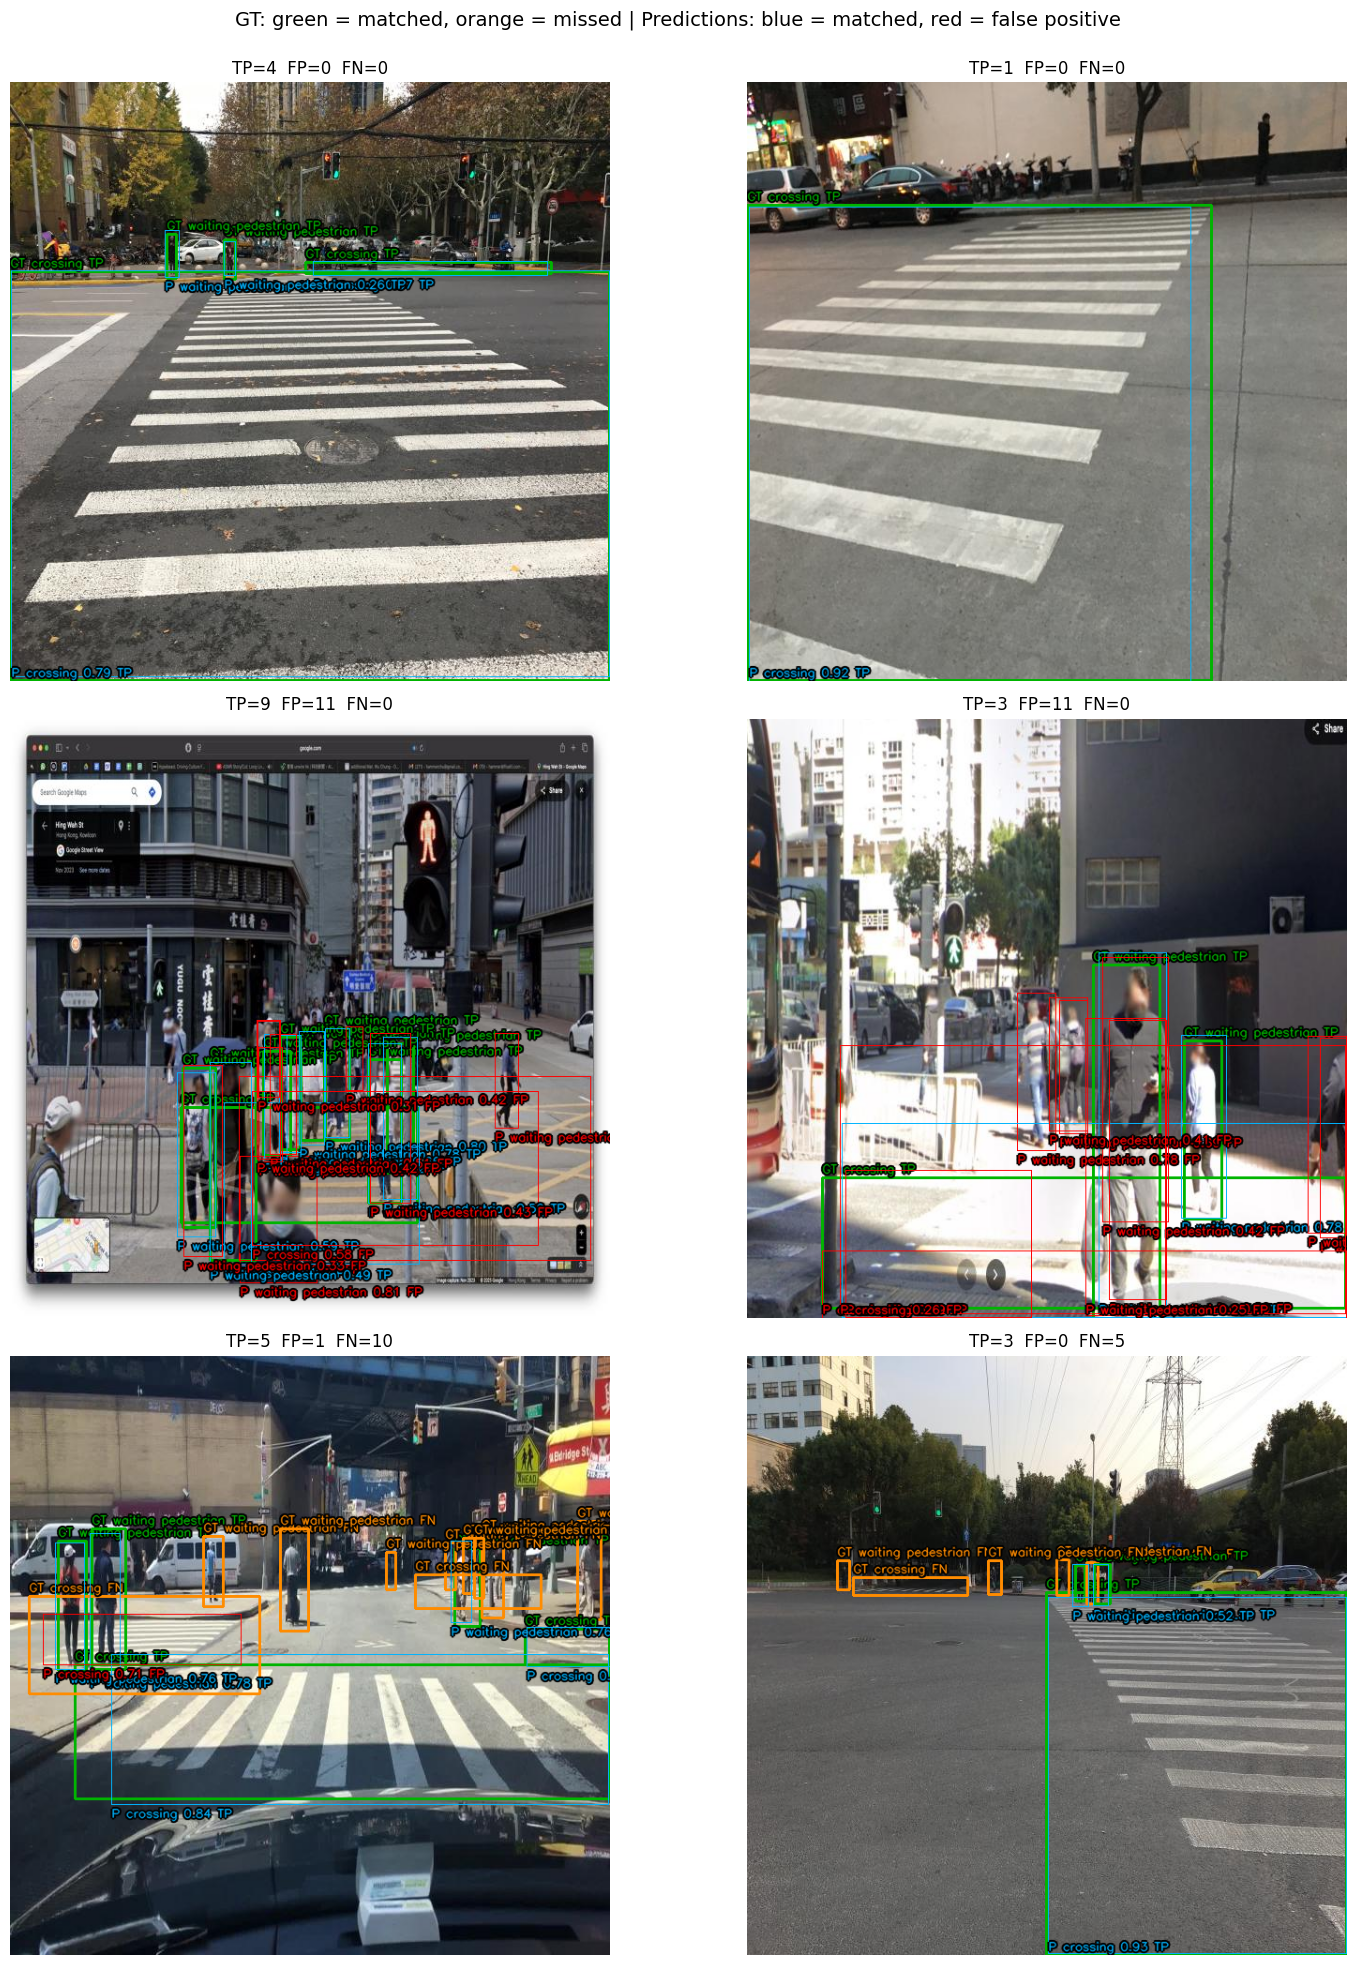

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(16, 20))

for axis, image_name in zip(axes.ravel(), selected_images):
    row = selected_table[selected_table["image"] == image_name].iloc[0]

    axis.imshow(annotated_case(image_name))
    axis.set_title(f"TP={row['TP']}  FP={row['FP']}  FN={row['FN']}")
    axis.axis("off")

fig.suptitle(
    "GT: green = matched, orange = missed | Predictions: blue = matched, red = false positive",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

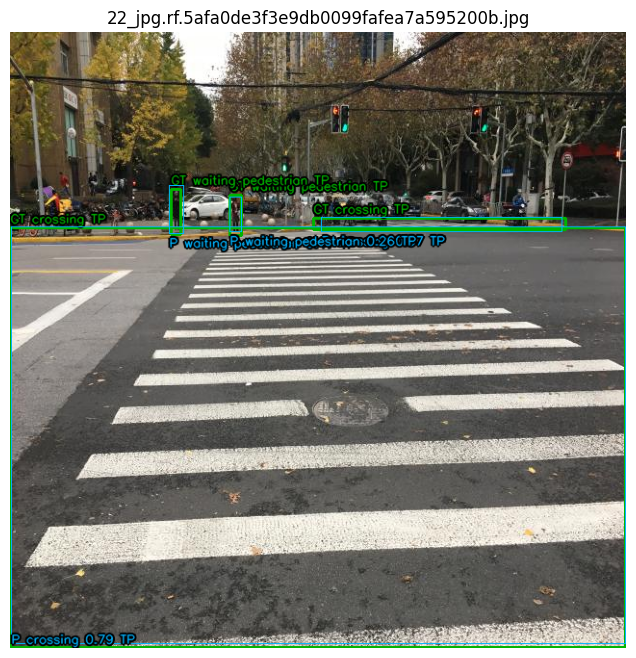

In [21]:
image_name = selected_images[0]

plt.figure(figsize=(12, 8))
plt.imshow(annotated_case(image_name))
plt.axis("off")
plt.title(image_name)
plt.show()